<a href="https://colab.research.google.com/github/Gan4x4/cv/blob/main/Convolutional_neural_network/Covolution 1D, 3D.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# Свертки 1D

Сигнал, который мы обрабатываем при помощи сверточного слоя, не обязательно должен быть картинкой и не обязательно он должен быть двумерным.

В качестве примера такого сигнала может выступать звук:

In [1]:
import torchaudio

dataset = torchaudio.datasets.YESNO("./", download=True)

100%|██████████| 4.49M/4.49M [00:01<00:00, 3.85MB/s]


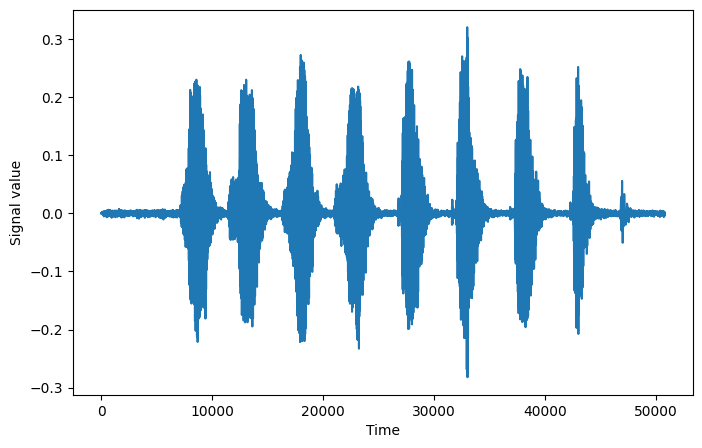

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.xlabel("Time")
plt.ylabel("Signal value")

waveform, sample_rate, label = dataset[0]

plt.plot(waveform.flatten())
plt.show()

В PyTorch одномерная свертка задается аналогично двумерной — `torch.nn.Conv1d` [🛠️[doc]](https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html):

```
torch.nn.Conv1d(in_channels, out_channels,             kernel_size, stride=1,  padding=0, ...)
```

Одномерная операция свертки используется для данных, имеющих последовательную структуру: текстов, аудиозаписей, цифровых сигналов. Как правило, такую структуру можно представить в виде изменения величины с течением времени.

In [3]:
from torch import nn

conv = nn.Conv1d(1, 16, 3, stride=2)
output = conv(waveform)
print(output.shape)

torch.Size([16, 25399])


Но такой сигнал чаще преобразуют в спектрограмму, а к ней уже можно применить 2D-свёртку:

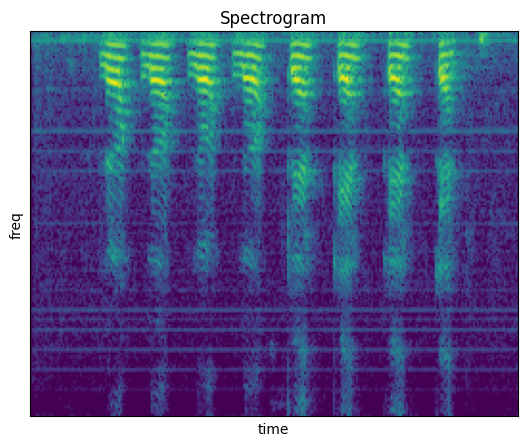

In [4]:
import librosa
from torchaudio.transforms import Spectrogram


spec_obj = Spectrogram(power=2, center=True, pad_mode="reflect")
spec = spec_obj(waveform[0])

plt.figure(figsize=(7, 5))
plt.imshow(librosa.power_to_db(spec))
plt.title("Spectrogram")
plt.xlabel("time")
plt.ylabel("freq")
plt.xticks([], [])
plt.yticks([], [])
plt.show()

## Дополнительная информация

Рассмотрим, как выглядит операция свертки в функциональном анализе.

Есть две различные функции, определяющие локальную "схожесть" функций $f(t)$ и $g(t)$:
- взаимнокорреляционная функция обозначается пятиконечной звездой <font size="8">$\large ⋆$</font> и определяет схожесть двух функций:
$$(f ⋆ g)(t)\stackrel{def}{=}  \int\limits_{-\infty}^{\infty}  f(\tau)g(t+\tau)d\tau$$
- свертка обозначается звездочкой (астериском) <font size="8">$*$</font> и определяет схожесть одной функции и "отраженной" другой функции:
$$\large(f * g)(t)\stackrel{def}{=}  \int\limits_{-\infty}^{\infty}  f(\tau)g(t-\tau)d\tau$$

Взаимная корреляция более интуитивно понятна: она представляет собой "наложение" шаблона на функцию, а свертка &mdash; "наложение" отраженного шаблона. Эти функции взаимосвязаны:
$$f(t) ⋆ g(t) = f(-t) * g(t)$$

Можно представить свертку как площадь произведения двух функций внутри скользящего окна, как на анимации ниже.

<img src ="https://ml.gan4x4.ru/msu/dev-2.2/L06/out/1d_convolution.gif" width="700">

В машинном обучении под словом **convolution** как правило [подразумевают **взаимнокорреляционную функцию** ✏️[blog]](https://glassboxmedicine.com/2019/07/26/convolution-vs-cross-correlation/), а не свертку. В реальности при обучении нейронной сети совершенно неважно, используется ли свертка или взаимнокорреляционная функция — они отличаются лишь порядком расположения весов внутри тензора ядра.

В случае дискретных величин для вычисления взаимной корреляции сигнал $f(t)$ поэлементно умножается со смещенным ядром $g(t)$, и результат суммируется:

$$\large(f \star g)(t) = f(1)g(t+1) + f(2)g(t+2) + f(3)g(t+3) + ...$$

### Свертка через перемножение матриц

Проводить вычисления при помощи вложенных циклов малоэффективно. Но операцию свертки можно реализовать через матричное умножение, которое очень эффективно выполняется на GPU

[[git] 🐾 Пример для 1D данных](https://github.com/Gan4x4/ml_snippets/blob/main/CV/Convolution_and_matrix_multiplication.ipynb)

Для двумерной свертки действует похожая логика, подробнее можно прочесть здесь:

[[blog] ✏️ 2D Convolution as a Matrix-Matrix Multiplication](https://www.baeldung.com/cs/convolution-matrix-multiplication)

И при получении градиентов это тоже работает:

[[blog] ✏️ Forward and Backward Convolution Passes as Matrix Multiplication](https://danieltakeshi.github.io/2019/03/09/conv-matmul/)

# Свертки 3D

Двумерная операция свертки, применяется для обработки данных, имеющих пространственную структуру, то есть тех данных, для которых играют роль взаимные расположения по двум осям. Совсем не обязательно, чтобы эти оси соответствовали высоте и ширине картинки. Например, одна ось может соответствовать координате сенсора в одномерной матрице, а вторая — времени получения информации с него.

Трёхмерная операция свертки используется, когда данные имеются три независимых "пространственных" компоненты.

Простейшим примером является видео: к двумерной структуре самих изображений добавляется координата времени.

<img src ="https://ml.gan4x4.ru/msu/dev-2.2/L06/out/3d_convolution.png" width="600">





```
 torch.nn.Conv3d(in_channels,
                  out_channels,
                  kernel_size,
                  stride=1,
                  padding=0,
                  dilation=1,
                  groups=1,
                  bias=True,
                  padding_mode='zeros')

```



In [5]:
import torch
from torch import nn

# With cubic kernels and same stride
conv = nn.Conv3d(in_channels=16, out_channels=33, kernel_size=3, stride=2)

# non-square kernels with unequal stride and padding
conv = nn.Conv3d(
    in_channels=16,
    out_channels=33,
    kernel_size=(3, 5, 2),
    stride=(2, 1, 1),
    padding=(4, 2, 0),
)

input = torch.randn(20, 16, 10, 50, 100)
out = conv(input)

print("out shape: ", out.shape)

out shape:  torch.Size([20, 33, 8, 50, 99])


### Медицинские 3D снимки

Другой популярный тип 3D-данных — это медицинские снимки (KT, МРТ). Для их хранения используются специальные форматы ([NIFTI ✏️[blog]](https://brainder.org/2012/09/23/the-nifti-file-format/), [DICOM 📚[wiki]](https://en.wikipedia.org/wiki/DICOM)).


Для работы с ними существуют специальные библиотеки. Воспользуемся одной из них — библиотекой [NiBabel 🛠️[doc]](https://nipy.org/nibabel/coordinate_systems.html), чтобы преобразовать файл из формата NIFTI в 3D-массив. Для этого скачаем образец МРТ мозга:



In [6]:
# !wget -q https://nipy.org/nibabel/_downloads/f76cc5a46e5368e2c779868abc49e497/someones_epi.nii.gz
!wget -q https://edunet.kea.su/repo/EduNet-web_dependencies/datasets/someones_epi.nii.gz

И откроем его при помощи NiBabel:

In [7]:
import nibabel as nib

epi_img = nib.load("someones_epi.nii.gz")
epi_img_data = epi_img.get_fdata()
print(epi_img_data.shape)
print("Max", epi_img_data.max(), "Min", epi_img_data.min())

(53, 61, 33)
Max 103.76662158966064 Min 7.742551803588867


Можно воспринимать этот массив как набор черно-белых изображений.

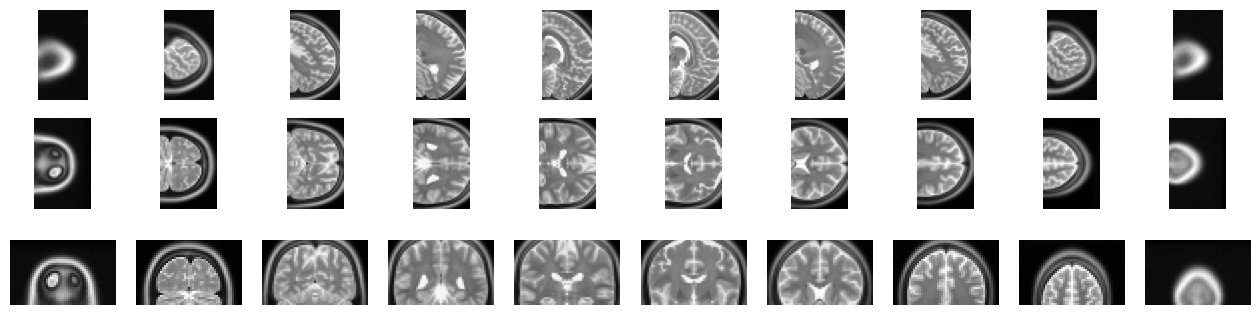

In [8]:
import numpy as np


def show_slices(ax, data):
    slices = np.linspace(0, len(data) - 1, num=10).astype(int)
    for i, sl in enumerate(slices):
        ax[i].axis("off")
        ax[i].imshow(data[sl], cmap="gray", origin="lower")


fig, axes = plt.subplots(3, 10, figsize=(16, 4))

show_slices(axes[0], epi_img_data)
show_slices(axes[1], np.moveaxis(epi_img_data, 0, 1))
show_slices(axes[2], np.moveaxis(epi_img_data, 0, 2))
plt.show()

Преобразуем массив в `torch.Tensor`. При этом добавим размерность для каналов:

In [9]:
import torch

brain_mrt = torch.Tensor(epi_img_data)
brain_mrt = brain_mrt.unsqueeze(0)  # add channel dim
print("Add channel dim", brain_mrt.shape)

Add channel dim torch.Size([1, 53, 61, 33])


Теперь можно подать его на вход `Conv3d`:

In [10]:
from torch import nn

conv3d = nn.Conv3d(
    in_channels=1,
    out_channels=16,
    kernel_size=(3, 3, 3),
    stride=(1, 1, 1),
    padding=(1, 1, 1),
)

out = conv3d(brain_mrt.unsqueeze(0))  # add batch dim and run inference

print("out shape: ", out.shape)

out shape:  torch.Size([1, 16, 53, 61, 33])
